<a href="https://colab.research.google.com/github/Gaurav9571/week1_Gaurav_Mittal/blob/main/Week_6_Gaurav_Mittal_autoencoder_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder MNIST

## Importing required packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

## Defining transforms

In [2]:
transforms=transforms.ToTensor()

## Downloading requried data

In [3]:
train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 67.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.85MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.1MB/s]


## Defining dataloaders

In [4]:
def add_gaussian_noise(images, noise_factor=0.2):
    """Adds Gaussian noise to a batch of images."""
    noisy_images = images + noise_factor * torch.randn_like(images)
    # Clip values to stay within the valid image range [0, 1]
    noisy_images = torch.clamp(noisy_images, 0., 1.)
    return noisy_images

In [5]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

In [6]:

# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [7]:
dataiter=iter(train_loader)
images,labels=next(dataiter)
print(images, images.shape, len(images), images[0].shape)
print()
print(labels,labels.shape,len(labels))

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

## Visualizing a Training batch

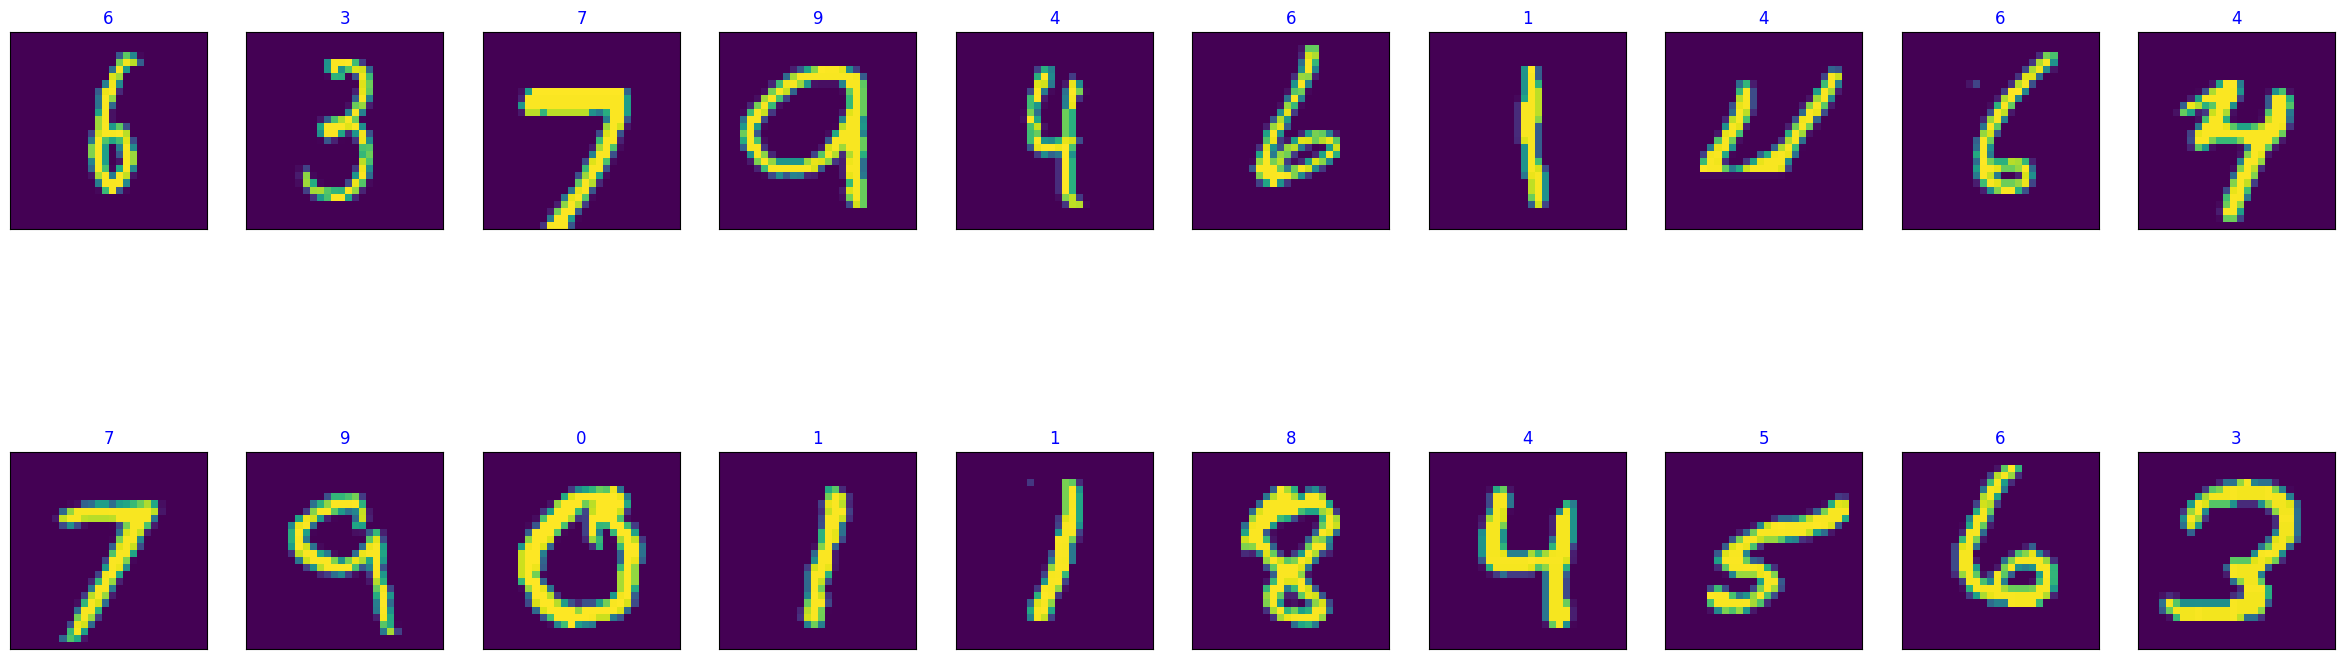

In [8]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

## Defining Architecture

In [9]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x

class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        # Note: nn.functional.upsample is deprecated. Using nn.functional.interpolate instead.
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x=F.sigmoid(self.de_conv2(x))
        return x

#Since the images are normalized between 0 and 1, we need to use a sigmoid activation on the output layer to get values that match this input value range.

In [10]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

## Defining our Loss Function

In [11]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

## Training and Validation Phase

In [12]:
def trainNet(model,lr,state='fully', denoising=False, noise_factor=0.2):
    optimizer=torch.optim.Adam(model.parameters(),lr=lr)

    # Number of epochs to train for
    loss_keeper={'train':[],'valid':[]}
    epochs=20

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
        model.train() # TURN ON DROPOUT for training
        for images,_ in train_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images # Keep original images as target
            if denoising:
                images = add_gaussian_noise(images, noise_factor) # Add noise to input

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,original_images) # Compare output to original clean images
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,_ in valid_loader:
            if use_cuda and torch.cuda.is_available():
                images=images.cuda()

            original_images = images # Keep original images as target
            if denoising:
                images = add_gaussian_noise(images, noise_factor) # Add noise to input

            if state=='fully':
                images=images.view(images.size(0),-1)
                original_images=original_images.view(original_images.size(0),-1)
            output=model(images)
            loss=criterion(output,original_images) # Compare output to original clean images
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_loader)
        valid_loss = valid_loss/len(valid_loader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model......."
            )
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_denoising_model.pth') # Save as denoising model
            valid_loss_min=valid_loss
    return(loss_keeper)

In [13]:
m1_loss=trainNet(model_1,0.01)


Epoch : 1	Training Loss : 0.03271046979585662	Validation Loss : 0.029332710076123477
Validation loss decreased from : inf ----> 0.029332710076123477 ----> Saving Model.......

Epoch : 2	Training Loss : 0.0290208254645889	Validation Loss : 0.02861465703075131
Validation loss decreased from : 0.029332710076123477 ----> 0.02861465703075131 ----> Saving Model.......

Epoch : 3	Training Loss : 0.028818728517120085	Validation Loss : 0.02826595847805341
Validation loss decreased from : 0.02861465703075131 ----> 0.02826595847805341 ----> Saving Model.......

Epoch : 4	Training Loss : 0.02869433966698125	Validation Loss : 0.028357802778482436

Epoch : 5	Training Loss : 0.02862317253680279	Validation Loss : 0.028317341993873316

Epoch : 6	Training Loss : 0.028582152888023606	Validation Loss : 0.02809209980381032
Validation loss decreased from : 0.02826595847805341 ----> 0.02809209980381032 ----> Saving Model.......

Epoch : 7	Training Loss : 0.028535399402026086	Validation Loss : 0.028135602318

In [14]:
m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.04161549453623593	Validation Loss : 0.02100819907616824
Validation loss decreased from : inf ----> 0.02100819907616824 ----> Saving Model.......

Epoch : 2	Training Loss : 0.0203553889078709	Validation Loss : 0.019636367339019974
Validation loss decreased from : 0.02100819907616824 ----> 0.019636367339019974 ----> Saving Model.......

Epoch : 3	Training Loss : 0.01959376870499303	Validation Loss : 0.019055769643746317
Validation loss decreased from : 0.019636367339019974 ----> 0.019055769643746317 ----> Saving Model.......

Epoch : 4	Training Loss : 0.01921628483532307	Validation Loss : 0.018830284102198978
Validation loss decreased from : 0.019055769643746317 ----> 0.018830284102198978 ----> Saving Model.......

Epoch : 5	Training Loss : 0.01899694594438188	Validation Loss : 0.01872035956165443
Validation loss decreased from : 0.018830284102198978 ----> 0.01872035956165443 ----> Saving Model.......

Epoch : 6	Training Loss : 0.01885563635888199	Validation 

In [15]:
m3_loss=trainNet(model_3,0.01,'conv')


Epoch : 1	Training Loss : 0.009903900823943938	Validation Loss : 0.007306593646450589
Validation loss decreased from : inf ----> 0.007306593646450589 ----> Saving Model.......

Epoch : 2	Training Loss : 0.007003674249281175	Validation Loss : 0.007556322796735912

Epoch : 3	Training Loss : 0.006737037355390688	Validation Loss : 0.006484523460579415
Validation loss decreased from : 0.007306593646450589 ----> 0.006484523460579415 ----> Saving Model.......

Epoch : 4	Training Loss : 0.006638567995590468	Validation Loss : 0.006354991334180037
Validation loss decreased from : 0.006484523460579415 ----> 0.006354991334180037 ----> Saving Model.......

Epoch : 5	Training Loss : 0.006554564907564782	Validation Loss : 0.006327824015946438
Validation loss decreased from : 0.006354991334180037 ----> 0.006327824015946438 ----> Saving Model.......

Epoch : 6	Training Loss : 0.006483995230131162	Validation Loss : 0.0062113731346714
Validation loss decreased from : 0.006327824015946438 ----> 0.0062113

In [29]:
# Re-initialize model_3 for denoising training
model_3_denoising = upsamp_conv_Auto_MNIST()

# Apply weight initialization if needed (Transpose CNN doesn't use Linear layers)
# model_3_denoising.apply(weight_init_normal)

# Move model to GPU if available
if use_cuda and torch.cuda.is_available():
    model_3_denoising.cuda()

# Train model_3 as a denoising autoencoder
m3_denoising_loss = trainNet(model_3_denoising, 0.001, 'conv', denoising=True, noise_factor=0.01)


Epoch : 1	Training Loss : 0.019154990435345097	Validation Loss : 0.010673173148340235
Validation loss decreased from : inf ----> 0.010673173148340235 ----> Saving Model.......

Epoch : 2	Training Loss : 0.010090361537489418	Validation Loss : 0.009305852348140131
Validation loss decreased from : 0.010673173148340235 ----> 0.009305852348140131 ----> Saving Model.......

Epoch : 3	Training Loss : 0.009100271372396189	Validation Loss : 0.008820739642251283
Validation loss decreased from : 0.009305852348140131 ----> 0.008820739642251283 ----> Saving Model.......

Epoch : 4	Training Loss : 0.008624420959192018	Validation Loss : 0.008276185692908862
Validation loss decreased from : 0.008820739642251283 ----> 0.008276185692908862 ----> Saving Model.......

Epoch : 5	Training Loss : 0.008348139633502191	Validation Loss : 0.00820367672247812
Validation loss decreased from : 0.008276185692908862 ----> 0.00820367672247812 ----> Saving Model.......

Epoch : 6	Training Loss : 0.00819429047134084	Va

In [30]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_denoising_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_denoising_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_denoising_model.pth'))

<All keys matched successfully>

## Plotting Loss

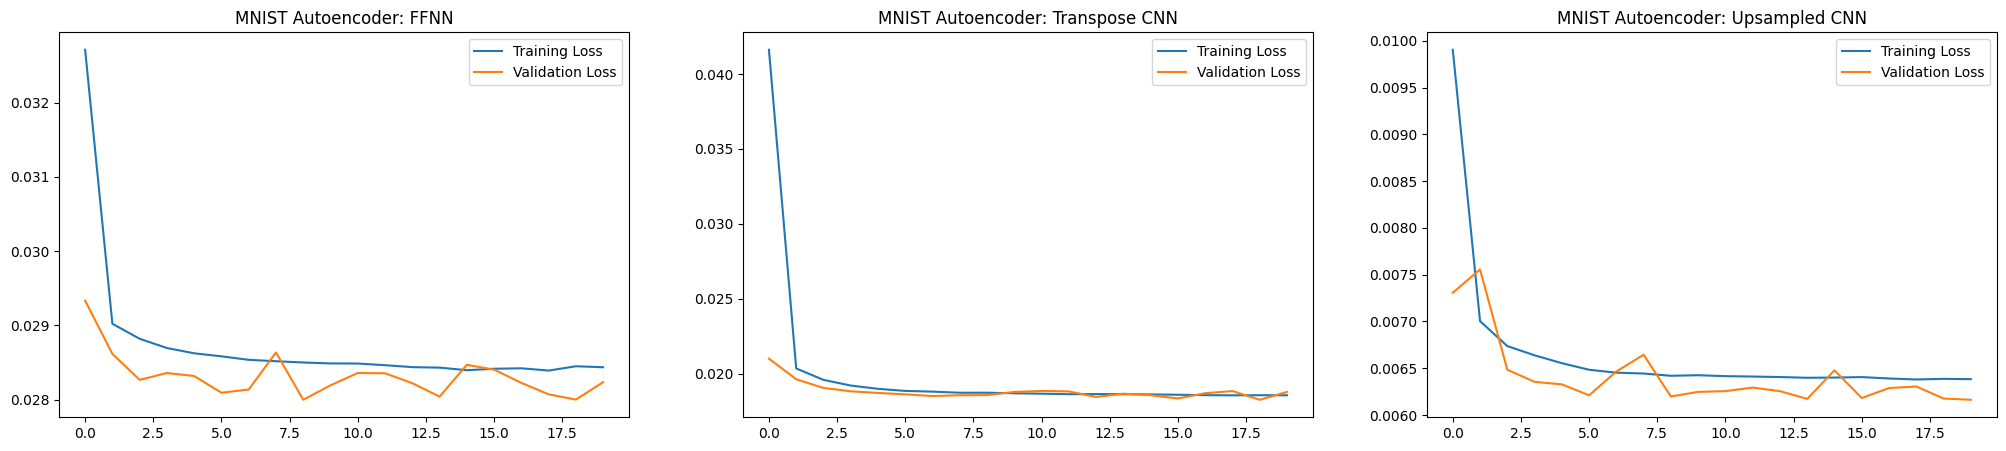

In [31]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

## Testing Phase

In [32]:
def test(model, state='fully', denoising=False, noise_factor=0.2):
    # obtain one batch of test images
    dataiter = iter(test_loader)
    images, _ = next(dataiter)

    if use_cuda and torch.cuda.is_available():
        images = images.cuda()

    # Keep original images for display later
    original_images_for_display = images.cpu().numpy()

    noisy_images = images # Initialize noisy_images with clean images
    if denoising:
        # Add noise to input images for the autoencoder
        noisy_images = add_gaussian_noise(images, noise_factor)

    # Store noisy images for display
    noisy_images_for_display = noisy_images.cpu().numpy()

    input_to_model = noisy_images # Model takes noisy images as input
    if state == 'fully':
        input_to_model = input_to_model.view(input_to_model.size(0), -1)

    # get sample outputs (denoised images)
    output = model(input_to_model)

    # Reshape output to image format and detach for numpy conversion
    output = output.view(batch_size, 1, 28, 28)
    denoised_images_for_display = output.cpu().detach().numpy()

    # plot the original, noisy, and then reconstructed images
    fig, axes = plt.subplots(nrows=3, ncols=10, sharex=True, sharey=True, figsize=(25, 6))

    # Original images on the first row
    for i in range(10):
        ax = axes[0, i]
        ax.imshow(np.squeeze(original_images_for_display[i]), cmap='gray')
        ax.set_title("Original", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    # Noisy images on the second row
    for i in range(10):
        ax = axes[1, i]
        ax.imshow(np.squeeze(noisy_images_for_display[i]), cmap='gray')
        ax.set_title(f"Noisy (factor={noise_factor})", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    # Reconstructed (denoised) images on the third row
    for i in range(10):
        ax = axes[2, i]
        ax.imshow(np.squeeze(denoised_images_for_display[i]), cmap='gray')
        ax.set_title("Denoised", fontsize=10)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()

## FFNN Autoencoder

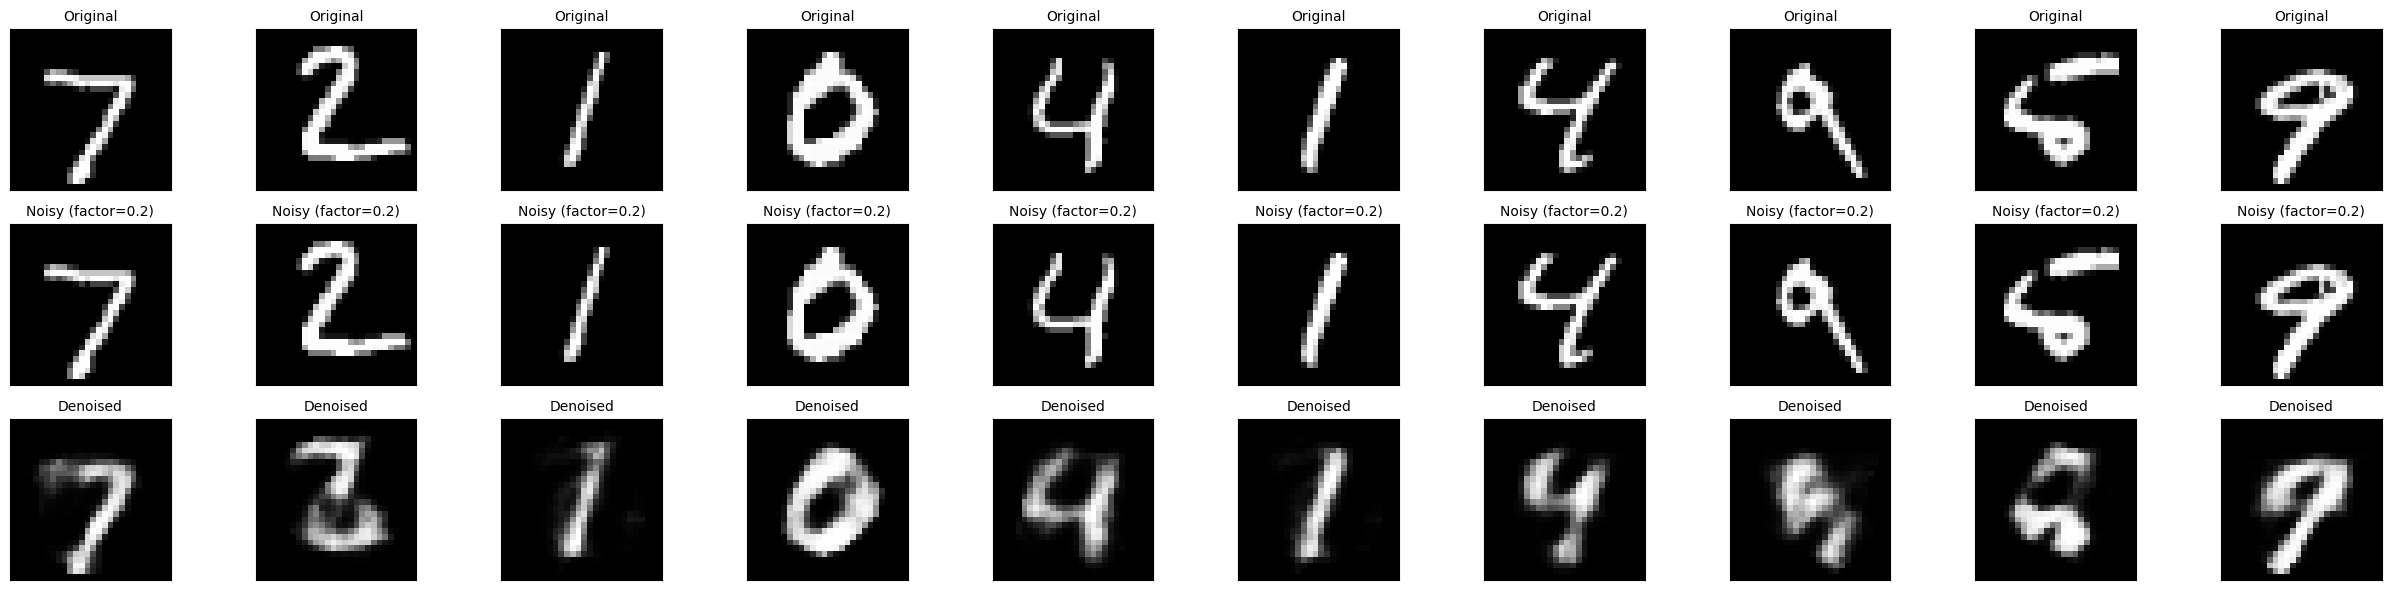

In [33]:
test(model_1)

## Transpose CNN Autoencoder

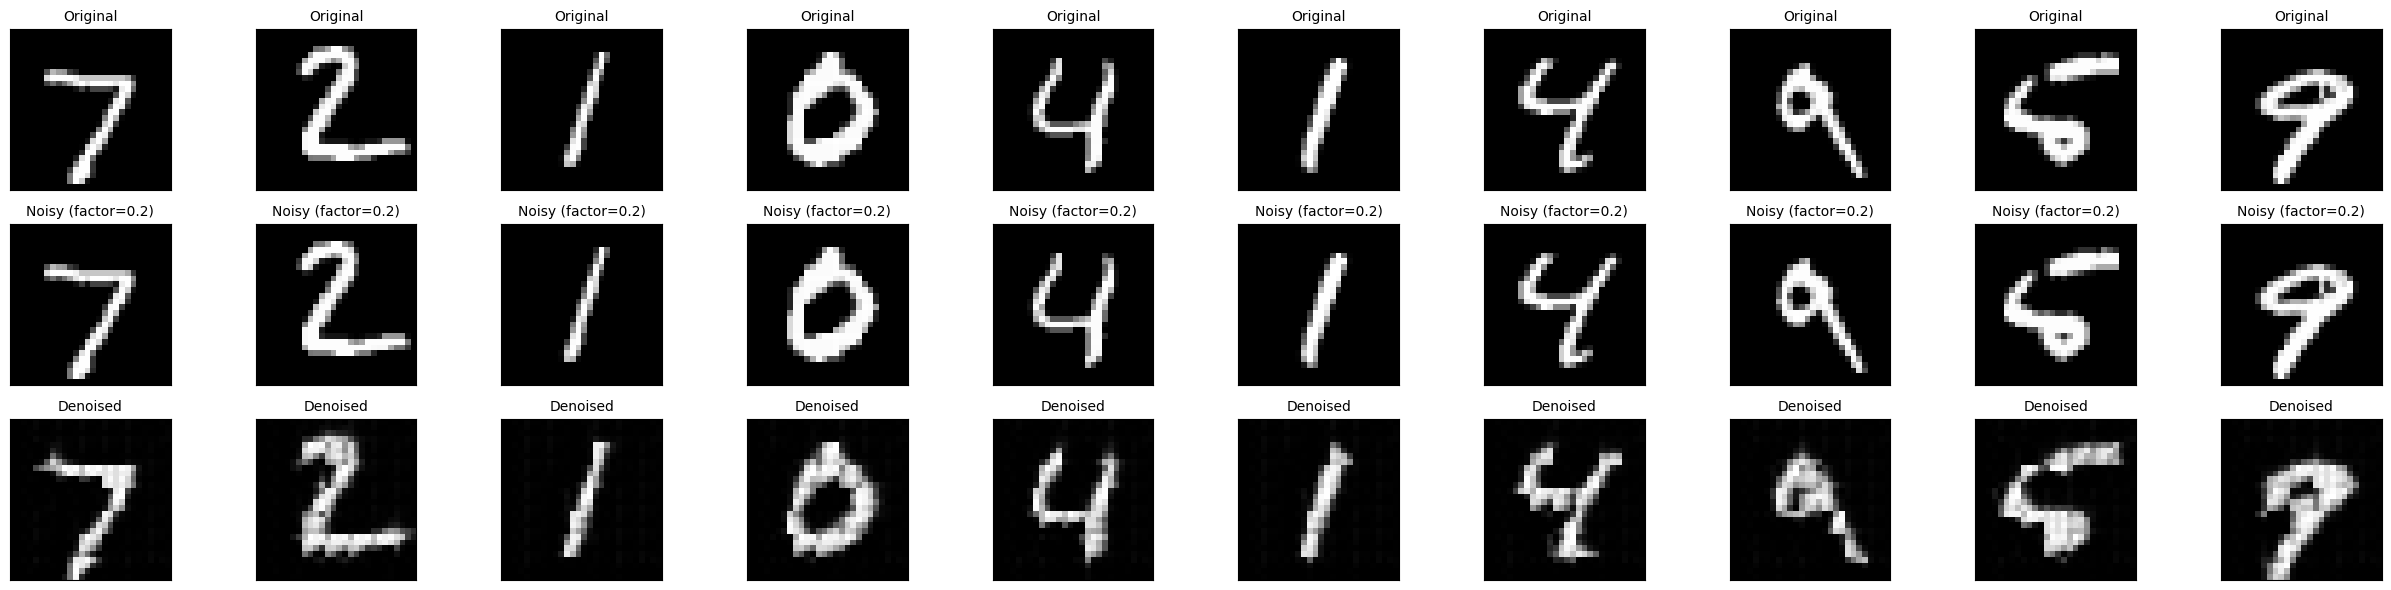

In [34]:
test(model_2,'conv')

## Upsampled CNN Autoencoder

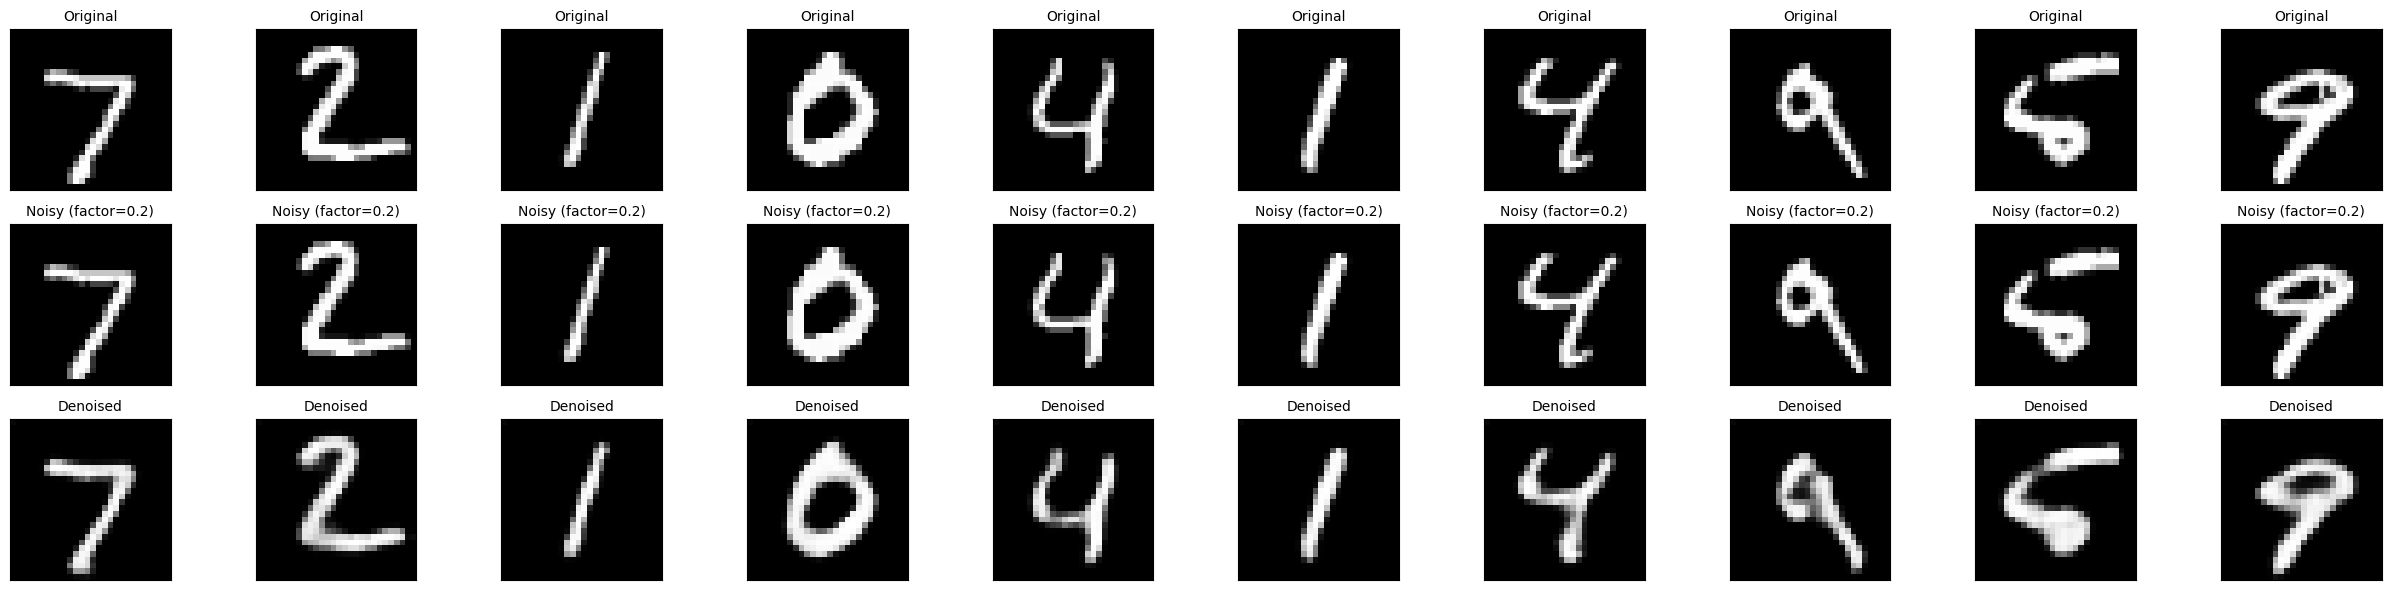

In [35]:
test(model_3,'conv')

Now, we will modify the `trainNet` function to introduce noise into the input images. The autoencoder will take these noisy images as input and try to reconstruct the original, clean images.

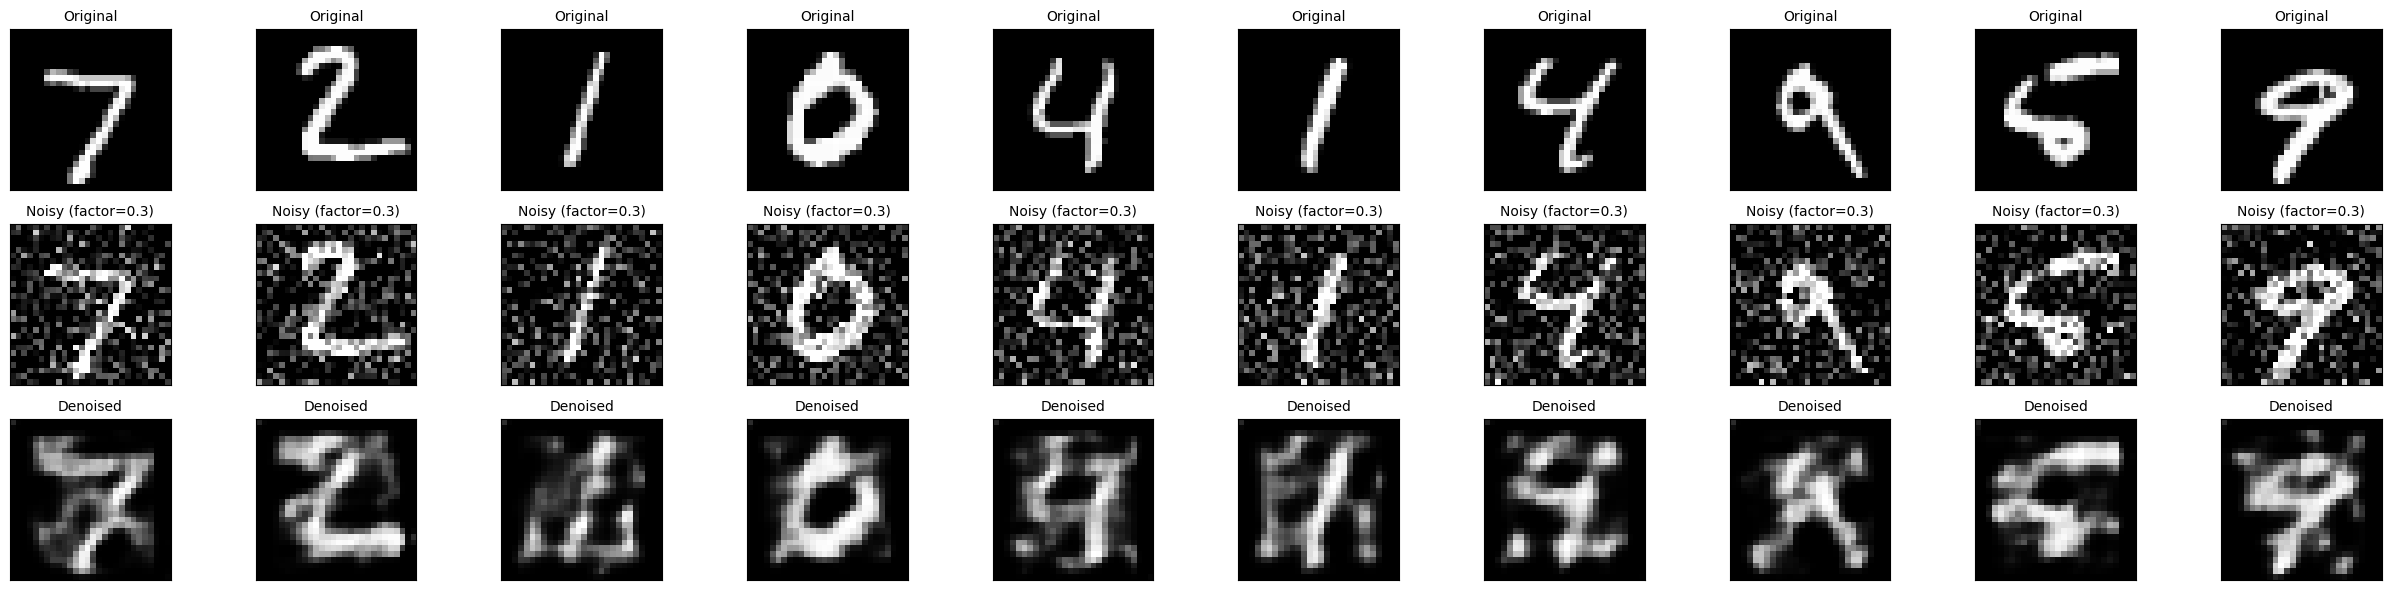

In [40]:
test(model_3_denoising, 'conv', denoising=True, noise_factor=0.3)